In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df=pd.read_csv("Customer Churn (1).csv")

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#Replacing blanks with 0 as tenure is 0 and no total charges are recorded 

In [7]:
df['TotalCharges']=df['TotalCharges'].replace(" ",'0')
df['TotalCharges']=df['TotalCharges'].astype("float")

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [10]:
df.duplicated().sum()

0

#converting 0 and 1 values of senior citizen to yes/no to make it easier to understand

In [11]:
df['SeniorCitizen']=df['SeniorCitizen'].replace(0,'No')
df['SeniorCitizen']=df['SeniorCitizen'].replace(1,'Yes')

In [12]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


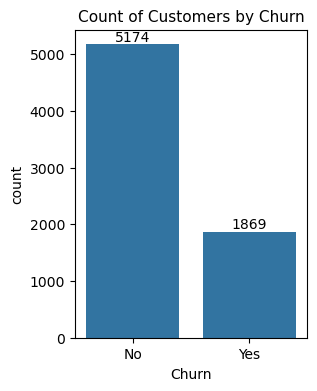

In [13]:
plt.figure(figsize=(3,4))
ax=sns.countplot(x=df['Churn'])
plt.title("Count of Customers by Churn",fontsize=11)
ax.bar_label(ax.containers[0])
plt.show()

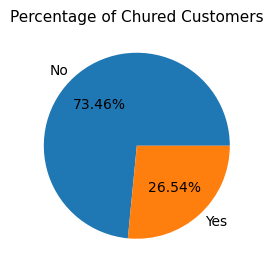

In [14]:
plt.figure(figsize=(3,4))
gb=df.groupby('Churn').agg({'Churn':'count'})
label=gb['Churn'].index
count=gb['Churn'].values
plt.pie(gb['Churn'],labels=label,autopct='%1.2f%%')
plt.title('Percentage of Chured Customers',fontsize=11)
plt.show()

#from the given pie chart we can conclude that 26.54% of our customers have churned out

#now let's explore the reason behind it

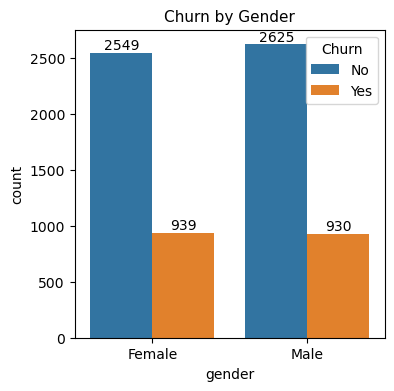

In [55]:
plt.figure(figsize=(4,4))
ax=sns.countplot(x=df['gender'],hue=df['Churn'])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churn by Gender",fontsize=11)
plt.show()

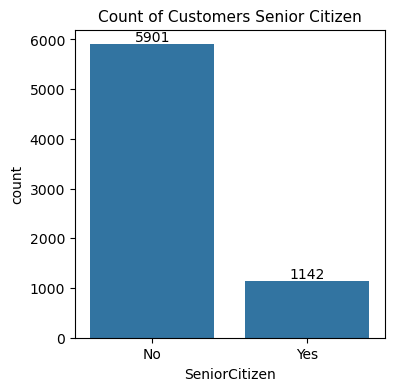

In [16]:
plt.figure(figsize=(4,4))
ax=sns.countplot(x=df['SeniorCitizen'])
ax.bar_label(ax.containers[0])
plt.title("Count of Customers Senior Citizen",fontsize=11)
plt.show()

<Figure size 400x400 with 0 Axes>

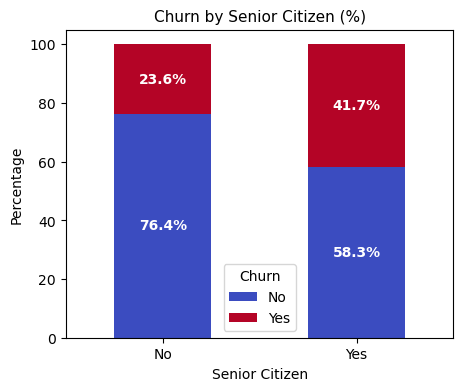

In [18]:
# Compute percentage counts
df_counts = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() * 100
plt.figure(figsize=(4,4))
# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(5, 4))
df_counts.plot(kind='bar', stacked=True, ax=ax, colormap='coolwarm')

# Add labels
for i, bars in enumerate(ax.containers):
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # Avoid placing labels for zero values
            ax.text(
                bar.get_x() + bar.get_width() / 2, 
                bar.get_y() + height / 2, 
                f'{height:.1f}%', 
                ha='center', va='center', fontsize=10, color='white', fontweight='bold'
            )

# Labels and title
ax.set_title("Churn by Senior Citizen (%)", fontsize=11)
ax.set_ylabel("Percentage")
ax.set_xlabel("Senior Citizen")
ax.legend(title="Churn", labels=['No', 'Yes'])
plt.xticks(rotation=0)

plt.show()

#comparative a greater percentage of people in senior citizen category have churned

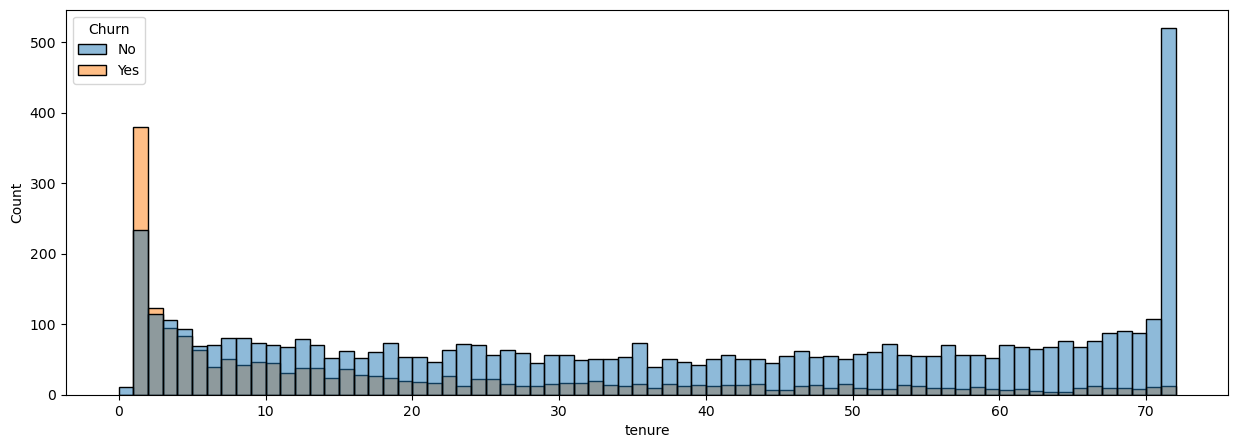

In [31]:
plt.figure(figsize=(15,5))
sns.histplot(x='tenure',data=df,bins=72,hue="Churn")
plt.show()

#people whi have used our services for a long time have stayed and people who have used our services 1 or 2 months have churned


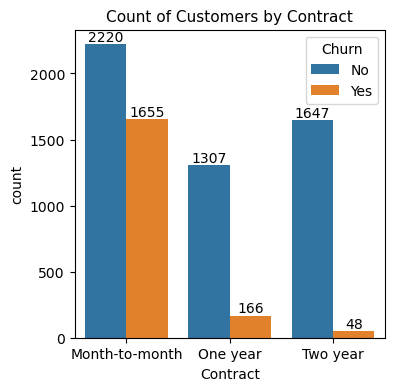

In [54]:
plt.figure(figsize=(4,4))
ax=sns.countplot(x=df['Contract'],hue=df["Churn"])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Count of Customers by Contract",fontsize=11)
plt.show()

#people who have month to month contract are likely to churn then from those who have 1 or 2 years contract

In [38]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

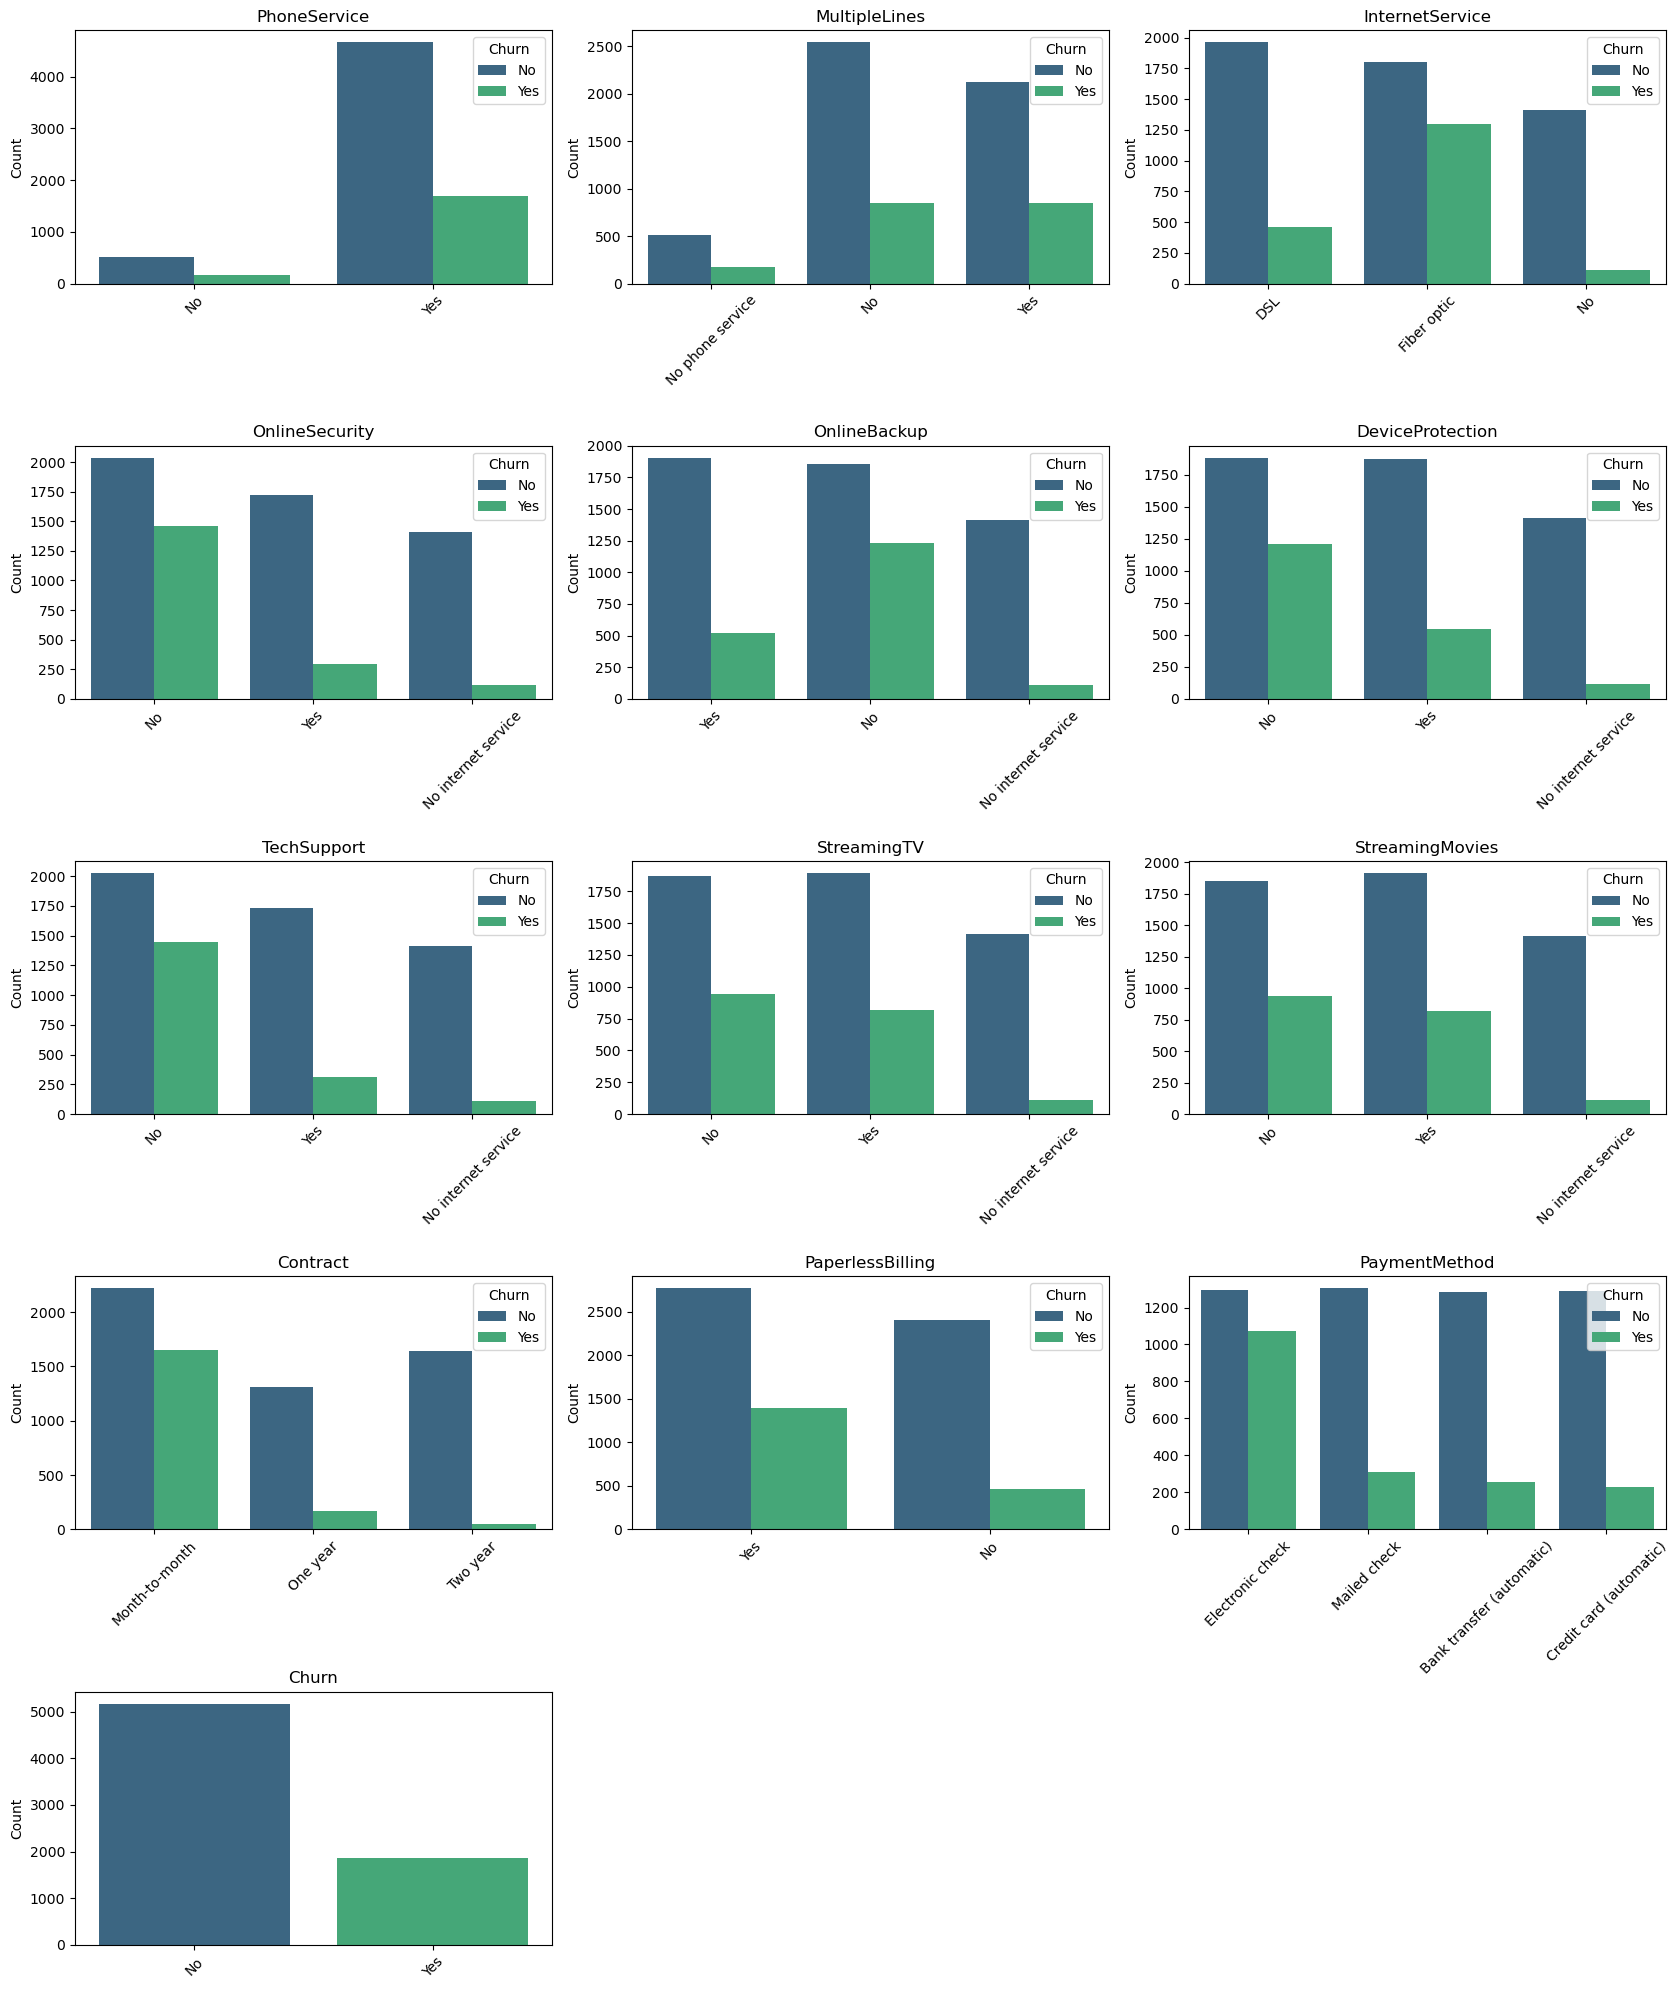

In [46]:
# List of categorical columns for count plots
categorical_columns = [
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'
]

# Define subplot layout
num_cols = 3  # Number of columns in subplot grid
num_rows = -(-len(categorical_columns) // num_cols)  # Calculate rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(17, 4 * num_rows))

# Flatten axes for easy iteration
axes = axes.flatten()

# Create count plots
for i, col in enumerate(categorical_columns):
    sns.countplot(data=df, x=col, ax=axes[i], palette="viridis",hue='Churn')
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplots
for i in range(len(categorical_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

#Count plots show distributions across various categorical features, such as Phone Service, Internet Service, Contract Type, and Payment Method. Most customers appear to prefer electronic billing and specific contract types, while services like Online Security and Tech Support have varying adoption rates. The Churn plot indicates a significant difference between retained and lost customers, suggesting key factors influencing customer attrition. Certain features, such as Monthly Charges and Contract Type, might have a stronger correlation with churn.

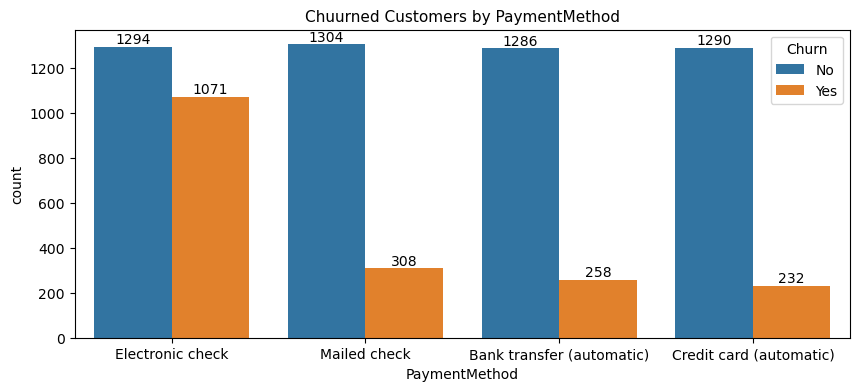

In [53]:
plt.figure(figsize=(10,4))
ax=sns.countplot(x=df['PaymentMethod'],hue=df["Churn"])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Chuurned Customers by PaymentMethod",fontsize=11)
plt.show()

#customer is likely to churn when he is using electronic check as a payment method.